### 3-variable RO model with ENSO southward wind shift
This 3-variable RO model is derived from the linear-reduced gravity model over the tropical ocean with ENSO southward wind shift (Iwakiri et al).

Key points of this study is summarized below.

- We extend the recharge oscillator theory to explicitly incorporate the effect of the ENSO southward wind shift
- meridional shift of zonal winds modulates ENSO stability by inducing an exponential decay of the thermocline feedback
- ENSO seasonal synchronization and combination mode can be sufficiently explained by the southward wind shift alone

This RO is implemented as follows
- seasonally varying zonal wind center, yc, is prescribed (derived from ENSO composite).
- Stochastically forced SST
- Integration: daily sub-steps averaged to monthly outputs.
- Outputs: time series of T, W, Z (with Z re-dimensionalized by Tk)
- Please see Fedorov (2010) for standard parameter set

##### Please see Iwakiri et al. for more detail.

In [54]:
# import library
import numpy as np
import matplotlib.pyplot as plt

#### 1) Configuration

In [55]:
NYEARS = 50                 # simulation length [years]
NDAYS_IN_MON = 30           # days per month (365_day calendar)
Tk = 2.4                    # months (nondimensionalization base)
SEED = 1000                 # RNG seed for reproducibility
USE_PROGRESS = False        # set True if you add tqdm

# Sampling / time step
dt = (1/30) / Tk            # 1 day in months, normalized by Tk
NSTEPS = NYEARS * 12
time_year = np.arange(NSTEPS) / 12.0

# Optional geographic conversion
LR = 340/111                # deg→nondim scale used for yc

#### 2) Standard parameters (nondimensional unless noted)

In [56]:
L     = 1
ck    = 1
xw    = 0
epsm  = 0.1
xc    = 0.4
tauo  = 0.62
H     = 1
D     = 0.63
nu    = 25
alpha = 0.11583         # (9°)^-2
epsT  = 0.57
d     = 0.42
Delta = 0.067
we    = 0.6
gammao= 0.5
q     = 0.142
r     = -0.014
pi    = np.pi


In [57]:
# Tuned parameter
we_dim = 1.275                 # [m/day]
we     = we_dim * 2.4 * 30 / 120  # nondim over Tk (e.g., 0.75 if 1.25 m/day)
epsw   = gammao * we / d
epsh   = tauo * epsw / Delta

# Stochastic forcing parameters (Zhao 2025)
xi_std = 2.361     # std of xi (a1=0 case)
xi_a1  = 0.211     # AR(1) coefficient

#- Seasonal yc (from ENSO composite; degrees)
#- July(0)-June(1) is used, but below yc_dim_sets are sorted for January to December.
yc_dim_sets = [
    -4.50751555, -4.81210016, -5.58116455, -4.13243975,  1.77086793, -0.24812707,
     1.68549662,  0.96208476,  1.20890946,  2.22261303, -0.20310714, -2.64528409
]

#### 3) Noise generator (monthly with daily internal stepping)

In [58]:
def gen_ar1_noise(stddev: float, n_year: int, ncopy: int, a1: float, seed: int):
    """
    AR(1) noise with daily steps aggregated to monthly outputs.
    Returns a flat array length n_year*12*NDAYS_IN_MON to be consumed each sub-step.
    """
    np.random.seed(seed)
    ncycle = NDAYS_IN_MON * 12
    red = stddev * np.random.normal(size=ncopy)
    noise_ts = np.full((n_year * ncycle, ncopy), np.nan)

    amp = np.sqrt(1 - a1 * a1)
    for iy in range(n_year):
        for ic in range(ncycle):
            red = a1 * red + amp * np.random.normal(size=ncopy)
            noise_ts[iy * ncycle + ic, :] = stddev * red
    return noise_ts.flatten()

noise_ts = gen_ar1_noise(stddev=xi_std, n_year=NYEARS, ncopy=1, a1=xi_a1, seed=SEED)

#### 4) Time integration

In [59]:
T, W, Z = 1, 0, 0 # initial condition

T_save = np.zeros(NSTEPS)
W_save = np.zeros(NSTEPS)
Z_save = np.zeros(NSTEPS)      # will store Z dimensionalized by Tk

tt = 0  # index into daily noise

step_iter = range(NSTEPS)
# If you prefer progress bar, wrap: from tqdm import tqdm; step_iter = tqdm(step_iter)
for step in step_iter:
    mon = step % 12
    yc = yc_dim_sets[mon] / LR

    # Seasonal coefficients
    R    = epsw + epsT - epsh * (r + q/np.sqrt(xc)) * np.exp(-alpha * yc**2)
    b    = q * epsh / (pi * np.sqrt(xc)) * np.exp(-alpha * yc**2)
    F1w  = b
    F1z  = b * alpha**2 * yc**2 / xc
    F2   = pi * alpha / (2 * xc)
    eps_w = epsm + alpha / (2 * xc)
    eps_z = epsm + alpha / xc

    # Daily sub-steps averaged to monthly means
    T_acc = 0.0
    W_acc = 0.0
    Z_acc = 0.0

    for _ in range(NDAYS_IN_MON):
        Tt = -R * T + F1w * W + F1z * Z + noise_ts[tt]
        Wt = -F2 * T - eps_w * W
        Zt =  pi * T + W - eps_z * Z

        T += dt * Tt
        W += dt * Wt
        Z += dt * Zt

        T_acc    += T / NDAYS_IN_MON
        W_acc    += W / NDAYS_IN_MON
        Z_acc    += Z / NDAYS_IN_MON
        tt += 1

    T_save[step] = T_acc
    W_save[step] = W_acc
    Z_save[step] = Z_acc * Tk     # re-dimensionalize Z to [K·month] with Tk

#### 5) Time series

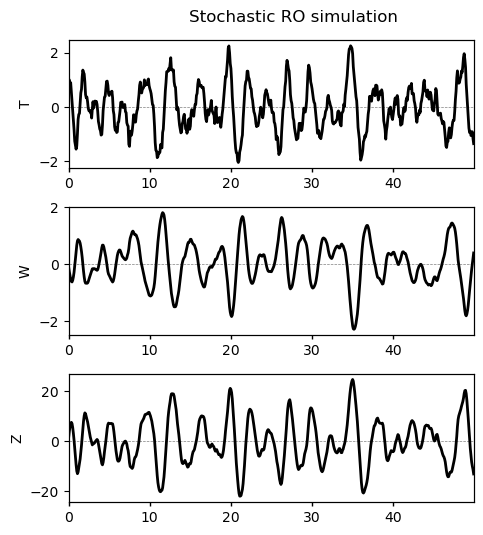

In [60]:
fig = plt.figure(figsize=(6, 6))

labels = ['T', 'W', 'Z']
series = [T_save, W_save, Z_save]

for i in range(3):
    ax1 = plt.subplot(3, 1, i+1)
    ax2 = ax1.twinx()  # empty twin axis to keep the same layout as原コード

    ax1.plot(time_year, series[i], color='black', lw=2, zorder=5)
    ax1.set_ylabel(labels[i])
    ax1.axhline(y=0, color='gray', lw=0.5, ls='dashed')
    ax1.set_xlim(time_year[0], time_year[-1])
    ax1.tick_params(length=3, width=1, which='major', axis='x')
    ax1.tick_params(length=5, width=2, which='minor', axis='x')

    ax2.set_yticks([])

plt.suptitle("Stochastic RO simulation", y=0.93)
plt.xlabel('Year')
fig.subplots_adjust(wspace=0.2, hspace=0.3, right=0.8)

#### 5) Seasonal synchronization

(-1.0, 12.0)

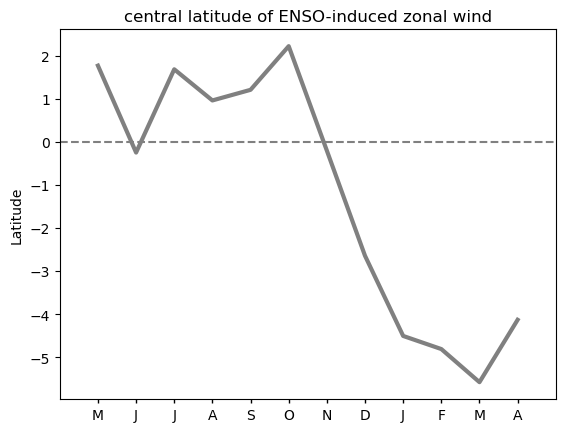

In [61]:

x=np.arange(12)
mon = np.array(['J','F','M','A','M','J','J','A','S','O','N','D'],dtype=str)

ax=plt.subplot(1,1,1)

idx = yc_dim_sets

ax1= plt.gca()

plt.plot(x, np.roll(idx,-4),color='gray',lw=3)

ax1.tick_params(length=3, width=1, which='major',axis='x')
ax1.tick_params(length=5, width=2, which='minor',axis='x')
plt.axhline(y=0, color='gray', ls='dashed')
plt.title("central latitude of ENSO-induced zonal wind")
plt.ylabel("Latitude")

plt.xticks(x, np.roll(mon,-4))
plt.xlim(-1,12)

(0.0, 1.4)

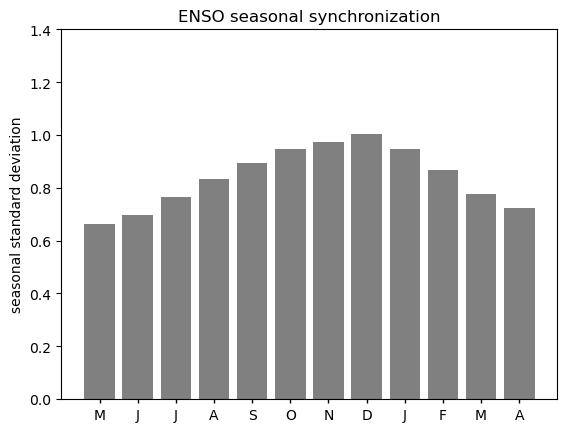

In [62]:

ax=plt.subplot(1,1,1)

idx, label = T_save, 'T'

nt = len(idx)
nyr= int(nt/12)
idx = idx.reshape(nyr,12)
idx = np.nanstd(idx, axis=0, ddof=1)

ax1= plt.gca()

plt.bar(x, np.roll(idx,-4),color='gray',lw=1)

ax1.tick_params(length=3, width=1, which='major',axis='x')
ax1.tick_params(length=5, width=2, which='minor',axis='x')
plt.title("ENSO seasonal synchronization")
plt.ylabel("seasonal standard deviation")

plt.xticks(x, np.roll(mon,-4))
plt.xlim(-1,12)
plt.ylim(0,1.4)